<a href="https://colab.research.google.com/github/eacasas/algoritmosOptimizacion/blob/main/ActividadGuiada2_EfraimCasas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Actividad Guiada Algoritmos de Optimización 2

Nombre: Efraím Alberto Casas Herrera

Enlace: https://colab.research.google.com/drive/1nynZfyFU_zoYJFx933zsBKNjlas1NvjF?hl=es#scrollTo=707Nu6rHfofl

https://github.com/eacasas/algoritmosOptimizacion

##Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas 

---

más pequeños, guardando las soluciones para ser utilizadas más 

---

adelante.

---


* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

###Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

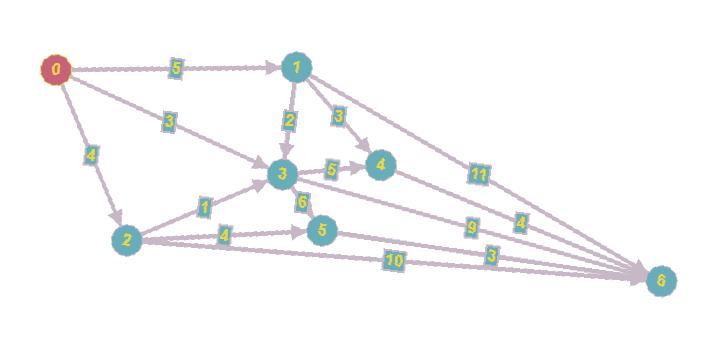

In [1]:
import math

In [2]:
#Viaje por el rio - Programación dinámica
################################################################################

#Se define la variable infinita para trabajar los máximos
X=float("inf")

TARIFAS = [
[0,5,4,3,X,X,X],    #desde nodo 0
[X,0,X,2,3,X,11],   #desde nodo 1
[X,X,0,1,X,4,10],   #desde nodo 2
[X,X,X,0,5,6,9],    #desde nodo 3
[X,X,X,X,0,X,4],    #desde nodo 4
[X,X,X,X,X,0,3],    #desde nodo 5
[X,X,X,X,X,X,0]     #desde nodo 6
]

TARIFAS

[[0, 5, 4, 3, inf, inf, inf],
 [inf, 0, inf, 2, 3, inf, 11],
 [inf, inf, 0, 1, inf, 4, 10],
 [inf, inf, inf, 0, 5, 6, 9],
 [inf, inf, inf, inf, 0, inf, 4],
 [inf, inf, inf, inf, inf, 0, 3],
 [inf, inf, inf, inf, inf, inf, 0]]

In [7]:
#Calculo de la matriz de PRECIOS y RUTAS

#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro

def Precios(TARIFAS):
  #Total de Nodos
  N = len(TARIFAS[0])
  
  #Inicialización de la tabla de precios
  PRECIOS = [ [X]*N for i in [X]*N]  #n x n 
  display(PRECIOS)
  RUTA = [ [""]*N for i in [""]*N]
  display(RUTA)
 
  #  Se construye la matriz de precios recorriendo todos lo nodos con dos bucles
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i
      
      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN
        
  return PRECIOS,RUTA

In [8]:
PRECIOS,RUTA = Precios(TARIFAS)  

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")  
for i in range(len(TARIFAS)):
  print(RUTA[i]) 

[[inf, inf, inf, inf, inf, inf, inf],
 [inf, inf, inf, inf, inf, inf, inf],
 [inf, inf, inf, inf, inf, inf, inf],
 [inf, inf, inf, inf, inf, inf, inf],
 [inf, inf, inf, inf, inf, inf, inf],
 [inf, inf, inf, inf, inf, inf, inf],
 [inf, inf, inf, inf, inf, inf, inf]]

[['', '', '', '', '', '', ''],
 ['', '', '', '', '', '', ''],
 ['', '', '', '', '', '', ''],
 ['', '', '', '', '', '', ''],
 ['', '', '', '', '', '', ''],
 ['', '', '', '', '', '', ''],
 ['', '', '', '', '', '', '']]

PRECIOS
[inf, 5, 4, 3, 8, 8, 11]
[inf, inf, inf, 2, 3, 8, 7]
[inf, inf, inf, 1, 6, 4, 7]
[inf, inf, inf, inf, 5, 6, 9]
[inf, inf, inf, inf, inf, inf, 4]
[inf, inf, inf, inf, inf, inf, 3]
[inf, inf, inf, inf, inf, inf, inf]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [10]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde 
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta]) 

print(f"La ruta es: {calcular_ruta(RUTA, 0,6) }")  


La ruta es: 0,2,5


##Problema de Asignacion de tarea

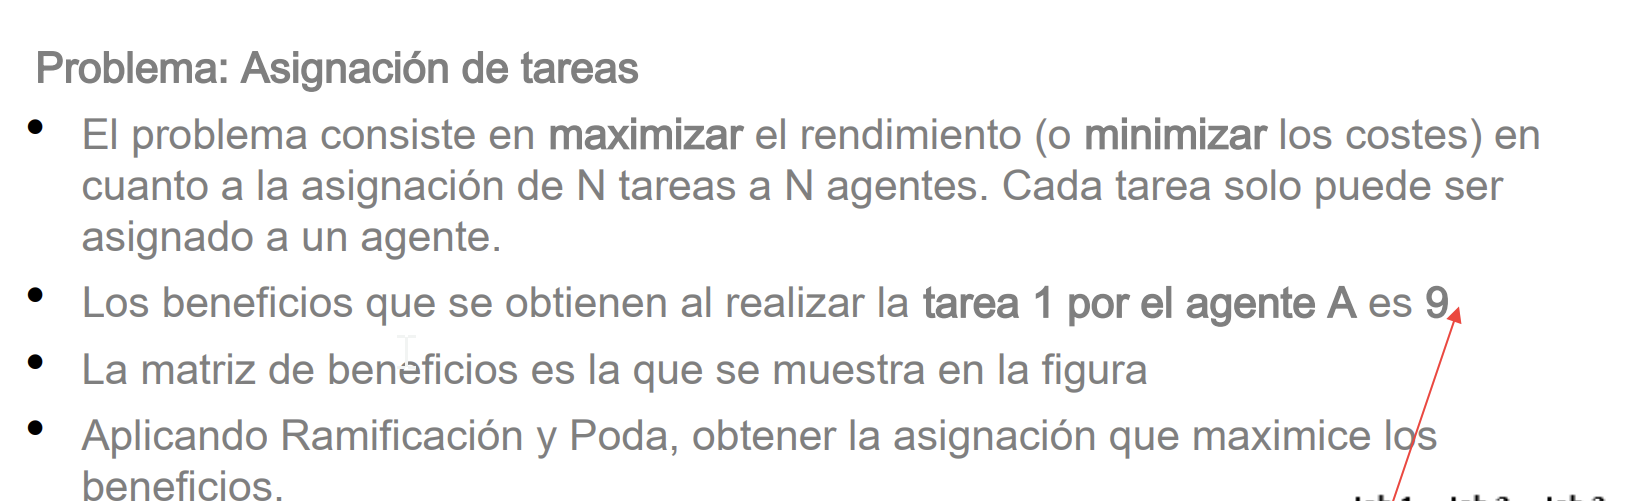

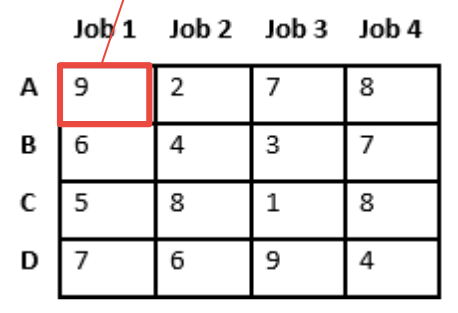

In [13]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    Tareas y Agentes

COSTES=[[9,2,7,8],
        [6,4,3,7],
        [5,8,1,8],
        [7,6,9,4]]

In [16]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((0,1),COSTES)

#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i] 
  return VALOR

In [11]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [43]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)  
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)} )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1
    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0: 
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL
 
    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos 
    NODOS.extend(HIJOS) 

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor]

  return MEJOR_SOLUCION   
  #print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  ) 


In [44]:
ramificacion_y_poda(COSTES)

[{'s': (1, 0, 2, 3), 'ci': 13}]

#Mejorar Nota

## 0. Problema de Asignacion de tarea por fuerza bruta



In [3]:
#    Tareas y Agentes

COSTES=[[9,2,7,8],
        [6,4,3,7],
        [5,8,1,8],
        [7,6,9,4]]

In [2]:
from itertools import permutations

def asignarTareas_FB(costes):
    #Se obtienen todas las posibles permutaciones de tareas
    tareas = list(range(len(costes[0])))
    permutaciones = permutations(tareas)
    mejor_asignacion = None
    mejor_puntuacion = float("inf")   

    for asignacion in permutaciones:
        #print(asignacion)
        puntuacion = 0
        for i, tarea in enumerate(asignacion):
            #print(f'i: {i}, tarea:{tarea}')            
            #Se suma el coste de la tarea correspondiente para cada agente
            puntuacion += costes[i][tarea]
        # Se guarda la mejor asignación
        if puntuacion < mejor_puntuacion:
            mejor_puntuacion = puntuacion
            mejor_asignacion = asignacion
    return [tareas[i] for i in mejor_asignacion]


In [4]:
print(f'La asignación de tareas es: {asignarTareas_FB(COSTES)}')

La asignación de tareas es: [1, 0, 2, 3]


## 1. Complejidad del algoritmo

La complejidad del algoritmo está dado por el número de permutaciones que puede tener la matriz, es decir n!

0(n) = n!

## 2. Generar matrices con valores aleatorios

In [7]:
import random

In [31]:
#Creamos una función para la generación de matrices nxn sin uso de librerías
def generador_matriz(n):
  matriz = [[0 for x in range(n)] for y in range(n)]
  # Recorrer cada elemento de la matriz y asignarle un número aleatorio
  for i in range(n):
      for j in range(n):
          matriz[i][j] = random.randint(0, 9)

  return(matriz)

In [9]:
generador_matriz(5)

[[1, 5, 6, 8, 6],
 [1, 8, 6, 9, 7],
 [2, 2, 5, 0, 6],
 [4, 9, 0, 5, 7],
 [9, 3, 1, 8, 2]]

### Generación dinamica de pruebas

Para esto vamos a evaluar ambos algoritmos con matrices desde valores de 3 en adelante.

In [20]:
import pandas as pd
import time

In [45]:
#Lista a evaluar, se evaluará hasta una matriz de 10x10
lista_n = [3,4,5,6,7,8,9,10]

#Para almacenar los resultados
resultados = pd.DataFrame(columns=['metodo','n','tiempo'])

#Se realizarán muestras desde 3 hasta 10. la misma matriz se analizará para ambos métodos

for n in lista_n:
  # Se crea una matriz aleatoria para ser evaluada con ambos algoritmos
  matriz_n = generador_matriz(n)
  
  #asignación por el método de ramificación y poda: RP
  t0 = time.perf_counter() 
  asignacion = ramificacion_y_poda(matriz_n)
  r= time.perf_counter()-t0
  new_row = {'metodo':'RP','n':n,'tiempo':r}
  resultados= resultados.append(new_row, ignore_index=True)


  #asignación por el método de fuerza bruta: FB
  t0 = time.perf_counter() 
  asignacion = asignarTareas_FB(matriz_n)
  r= time.perf_counter()-t0
  new_row = {'metodo':'FB','n':n,'tiempo':r}
  resultados= resultados.append(new_row, ignore_index=True)

In [46]:
display(resultados)

,metodo,n,tiempo
0,RP,3,0.000075
1,FB,3,0.000056
2,RP,4,0.000251
3,FB,4,0.000029
4,RP,5,0.000339
5,FB,5,0.000104
6,RP,6,0.003128
7,FB,6,0.000664
8,RP,7,0.025676
9,FB,7,0.004994


#### Visualización de resultados

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

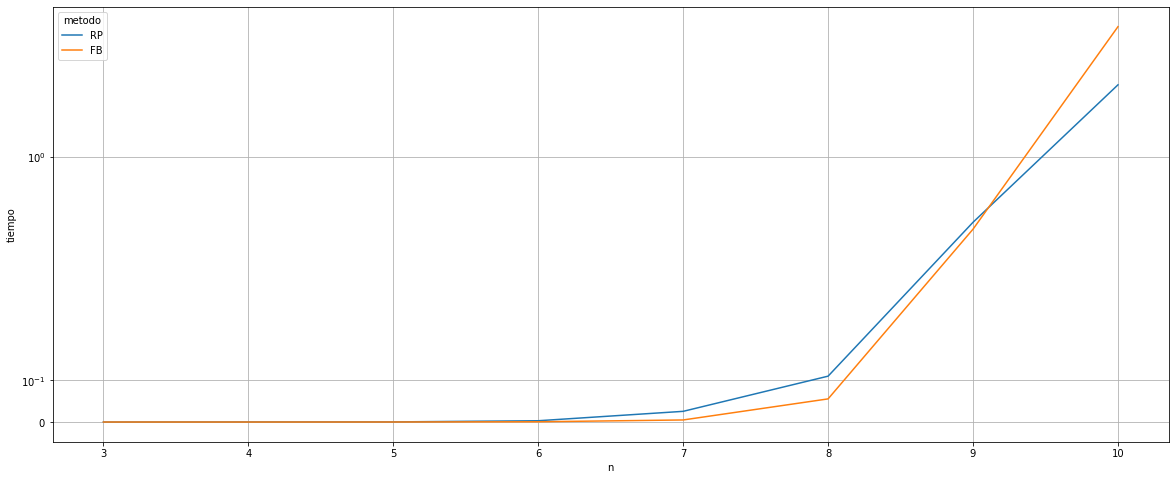

In [48]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('linear')
plt.yscale('log')
ax.set_yscale('symlog', linthreshy=0.5)
ax.grid()
sns.lineplot(data = resultados,
             x ='n',
             y ='tiempo',
             hue='metodo',
             markers=True,
             dashes=False,
             ax=ax)

###3. ¿A partir de qué dimensión el algoritmo por fuerza bruta deja de ser una opción?

después de 10 interacciones se puede ver el crecimiento acelerado del algoritmo y con tiempos de mas de 4 segundos, mientras que el algoritmo de ramificación y poda está aproximadamente en la mitad del tiempo


###4. ¿Hay algún valor de la dimensión a partir de la cual el algoritmo de ramificación y poda deja de ser una opción válida?

Se puede resolver de forma teorica y también validar en la práctica. 

In [ ]:
#Valores de matriz a evaluar
lista_n = list(range(10,15,1))
print(f'Se evaluará el algoritmo con los siguientes n: {lista_n}')

#Para almacenar los resultados
resultados = pd.DataFrame(columns=['metodo','n','tiempo'])

#Se realizarán muestras desde 3 hasta 10. la misma matriz se analizará para ambos métodos

for n in lista_n:
  # Se crea una matriz aleatoria para ser evaluada con ambos algoritmos
  matriz_n = generador_matriz(n)
  
  #asignación por el método de ramificación y poda: RP
  t0 = time.perf_counter() 
  asignacion = ramificacion_y_poda(matriz_n)
  #print(asignacion)
  r= time.perf_counter()-t0
  new_row = {'metodo':'RP','n':n,'tiempo':r}
  resultados= resultados.append(new_row, ignore_index=True)

Se evaluará el algoritmo con los siguientes n: [10, 11, 12, 13, 14]
